# Notebook for measuring correlation for disk scheme

In [1]:
import os
import sys

def find_project_root(target_folder="masteroppgave"):
    """Find the absolute path of a folder by searching upward."""
    currentdir = os.path.abspath("__file__")  # Get absolute script path
    while True:
        if os.path.basename(currentdir) == target_folder:
            return currentdir  # Found the target folder
        parentdir = os.path.dirname(currentdir)
        if parentdir == currentdir:  # Stop at filesystem root
            return None
        currentdir = parentdir  # Move one level up

# Example usage
project_root = find_project_root("masteroppgave")

if project_root:
    sys.path.append(project_root)
    print(f"Project root found: {project_root}")
else:
    raise RuntimeError("Could not find 'masteroppgave' directory")

from computation.similarity import *
from result_analysis.disk_correlation_bucketing import *


Project root found: /Users/thomasnitsche/Developer/skole/master/masteroppgave


/Users/thomasnitsche/Developer/skole/master/masteroppgave/result_analysis/disk_correlation_bucketing.py:568: SyntaxWarning: invalid escape sequence '\-'
  ax2.set_ylabel("Standard deviation \- Dashed lines", fontsize=16)
/Users/thomasnitsche/Developer/skole/master/masteroppgave/result_analysis/disk_correlation_bucketing.py:685: SyntaxWarning: invalid escape sequence '\-'
  ax2.set_ylabel("Standard deviation \- Dashed lines", fontsize=16)
/Users/thomasnitsche/Developer/skole/master/masteroppgave/result_analysis/disk_correlation_bucketing.py:804: SyntaxWarning: invalid escape sequence '\-'
  ax2.set_ylabel("Standard deviation \- Dashed lines", fontsize=16)


In [2]:
CITY = "rome" # "rome" or "porto"
MEASURE = "dtw" # "dtw" or "frechet"
SIZE = 50 #How many trajectories to use

# True sim matrix

In [3]:
file_path = f"../../results_true/similarity_values/{CITY}/{MEASURE}/{CITY}-{MEASURE}-{SIZE}.csv"

# Read CSV, telling pandas to take the first column as the row labels:
true_sim_matrix_df_unsymetric = pd.read_csv(file_path, index_col=0)

# Function to convert values to float if possible
def convert_to_float(value):
    try:
        return float(value)
    except ValueError:
        return value

# Apply the function to each cell in the DataFrame
true_sim_matrix_df = true_sim_matrix_df_unsymetric.map(convert_to_float)
true_sim_matrix_df = (true_sim_matrix_df + true_sim_matrix_df.T)


# true_sim_matrix_df

In [4]:

disk_corr_configs = {
    "layers:": "layers", #ferdig
    "disks" : "disks", #Ferdig
    "diameter": "diameter",  #Ferdig
    "size": "size", #ferdig
    "disks_layers": "disks_layers", #Ferdig
    "disks_diameter": "disks_diameter",  #ferdig
    "diameter_layers": "diameter_layers",  #ferdig
}

       R_AKY  R_AZS  R_BML  R_BRF  R_BTH  R_CFV  R_CNH  R_DAQ  R_EBK  R_EFS
R_AKY    0.0    0.0    NaN    0.0    NaN    0.0    NaN    0.0    0.0    0.0
R_AZS    0.0    0.0    NaN    0.0    NaN    0.0    NaN    0.0    0.0    0.0
R_BML    NaN    NaN    0.0    NaN    NaN    NaN    0.0    NaN    NaN    NaN
R_BRF    0.0    0.0    NaN    0.0    NaN    0.0    NaN    0.0    0.0    0.0
R_BTH    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN
R_CFV    0.0    0.0    NaN    0.0    NaN    0.0    NaN    0.0    0.0    0.0
R_CNH    NaN    NaN    0.0    NaN    NaN    NaN    0.0    NaN    NaN    NaN
R_DAQ    0.0    0.0    NaN    0.0    NaN    0.0    NaN    0.0    0.0    0.0
R_EBK    0.0    0.0    NaN    0.0    NaN    0.0    NaN    0.0    0.0    0.0
R_EFS    0.0    0.0    NaN    0.0    NaN    0.0    NaN    0.0    0.0    0.0
          R_AKY     R_AZS     R_BML  ...     R_DAQ     R_EBK  R_EFS
R_AKY  0.000000  0.000000  0.000000  ...  0.000000  0.000000    0.0
R_AZS  0.941472  0.000000  0

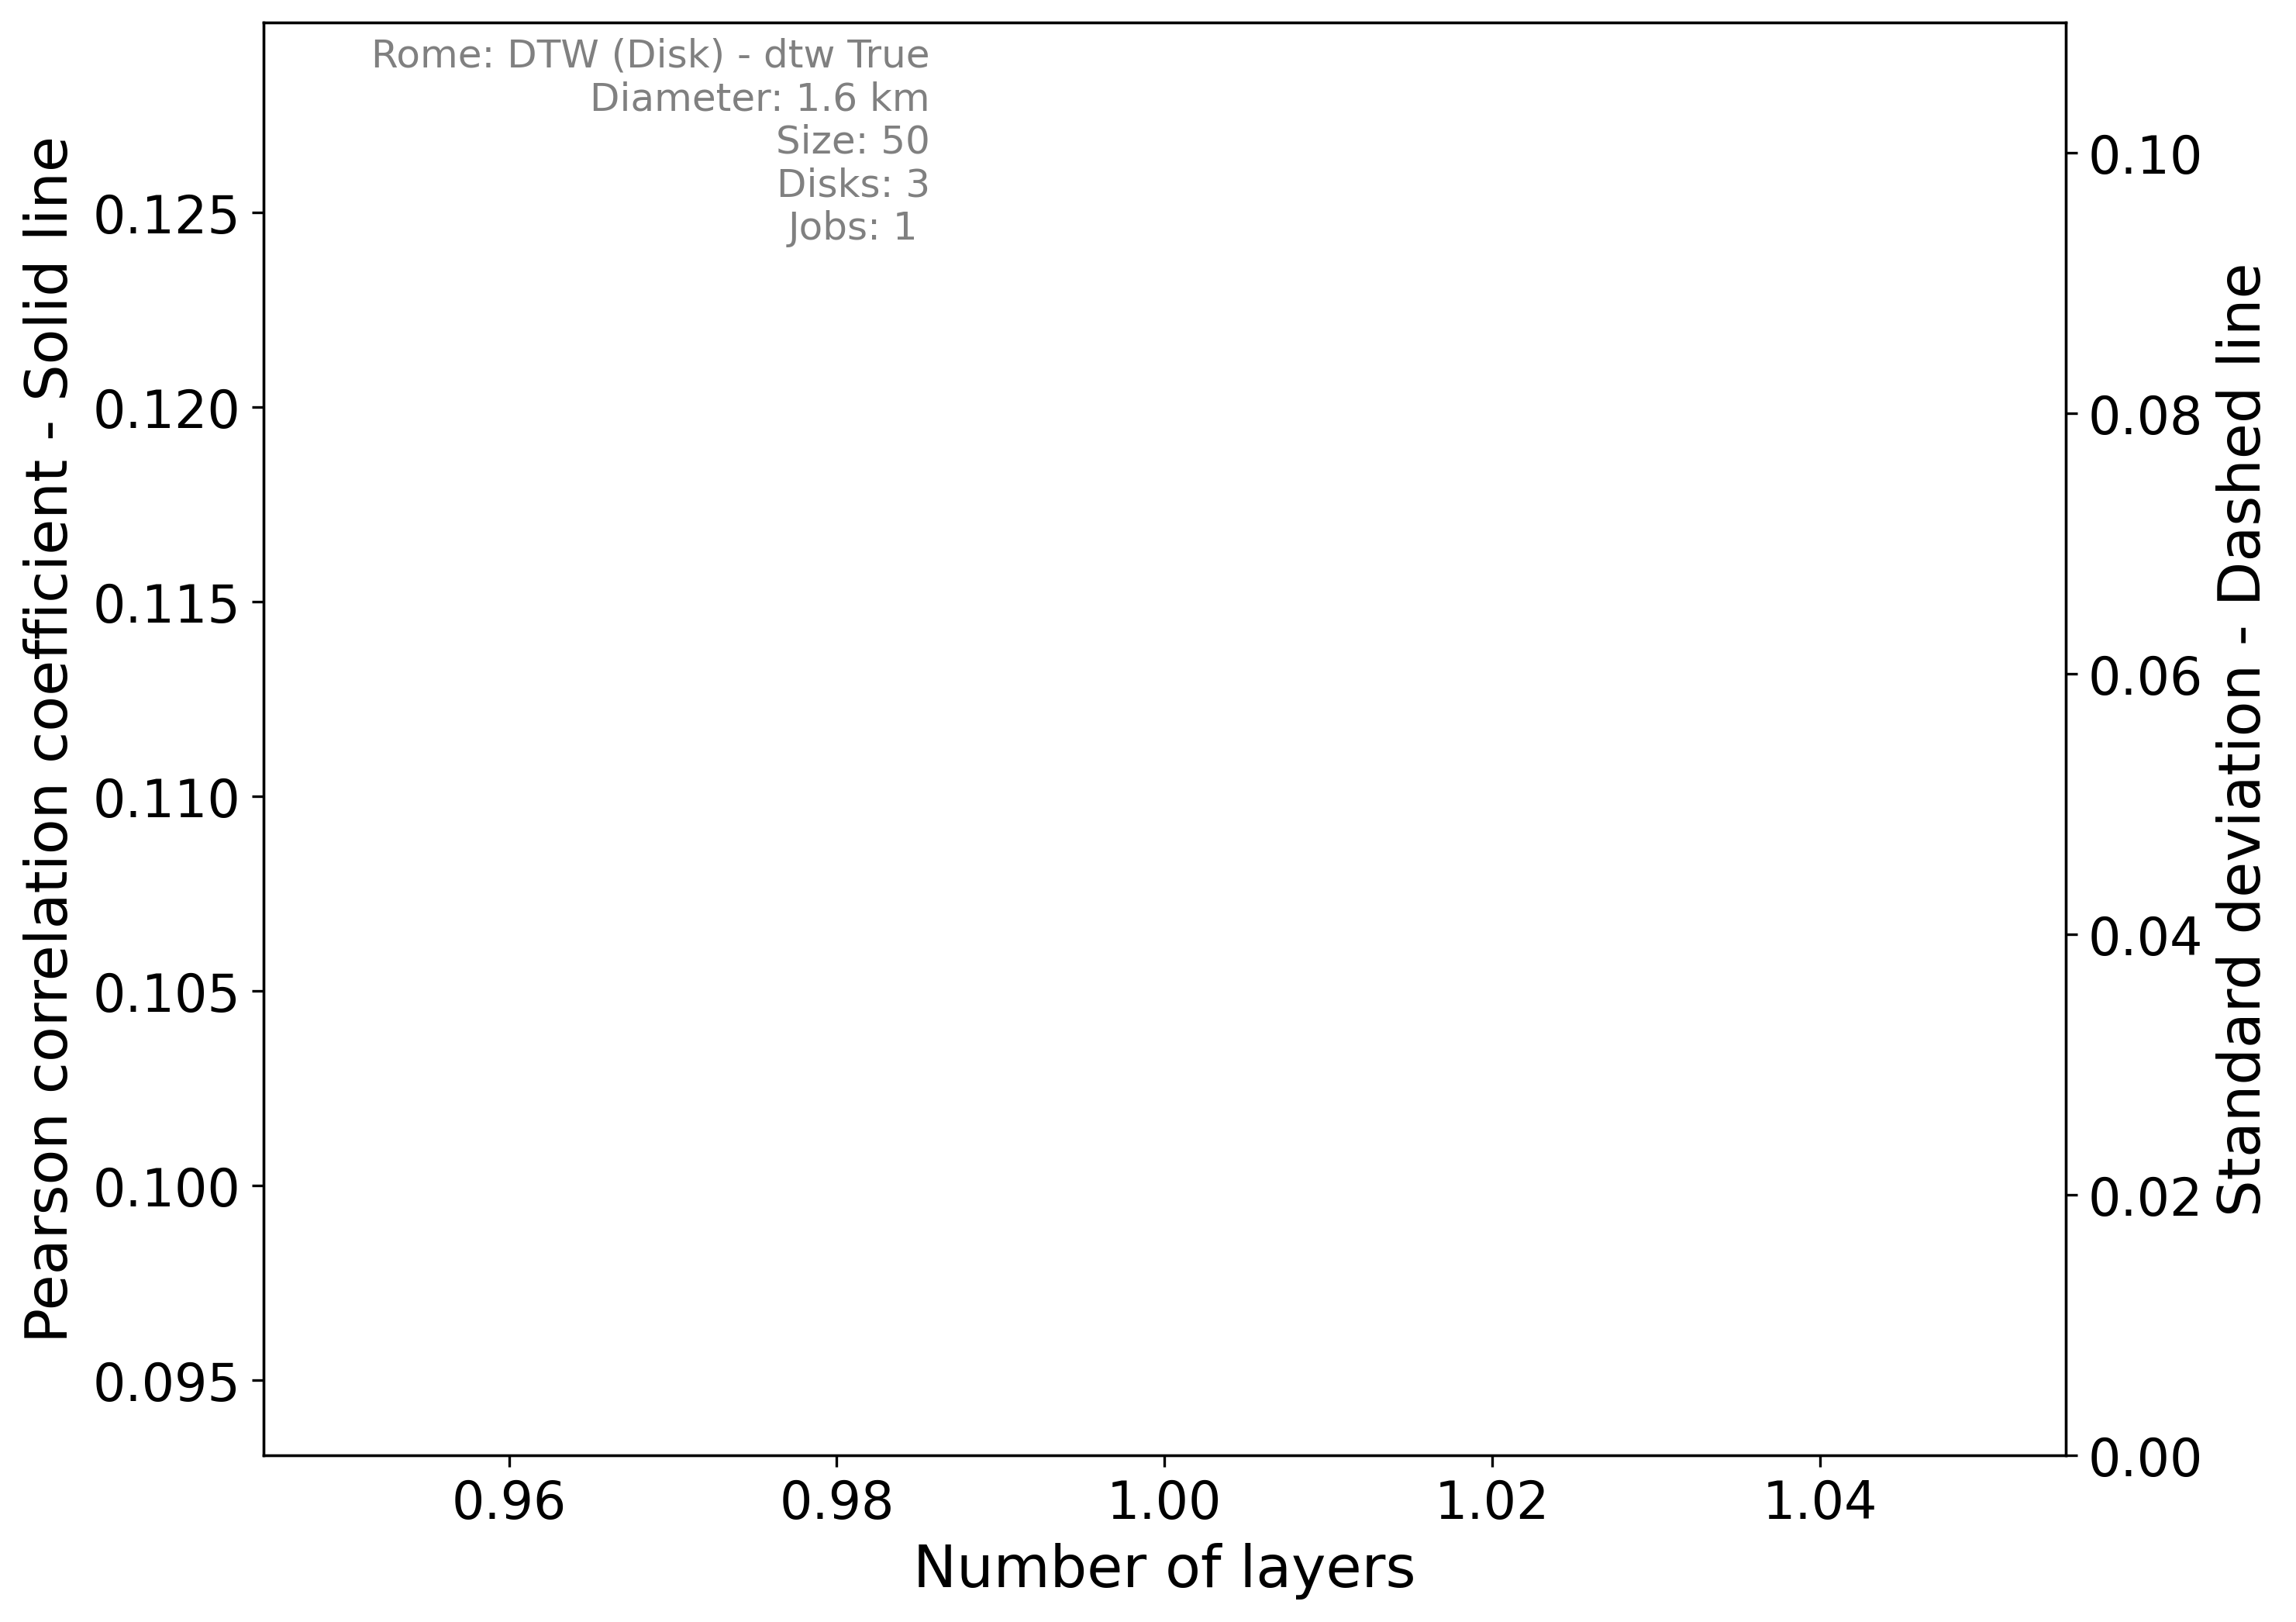

In [13]:
plot_disk_corr_varying_layers_bucketing(
    city=CITY,
    layers=[1],
    true_sim_matrix = true_sim_matrix_df_unsymetric,
    diameter=1.6,
    disks=3,
    size=SIZE,
    bucketing_method="loose",
    measure=MEASURE,
    parallel_jobs=1,
)

In [6]:
# plot_disk_corr_varying_disks_bucketing(
#     city=CITY,
#     layers=3,
#     true_sim_matrix = true_sim_matrix_df_unsymetric,
#     diameter=1.6,
#     disks=[30, 40, 50 ],
#     size=SIZE,
#     bucketing_method="loose",
#     measure=MEASURE,
#     parallel_jobs=10,
# )

In [7]:
# plot_disk_corr_varying_diameter_bucketing(
#     city=CITY,
#     layers=3,
#     true_sim_matrix = true_sim_matrix_df_unsymetric,
#     diameter= [1.2,2.1,0.1],
#     disks= 50,
#     size=SIZE,
#     bucketing_method="loose",
#     measure=MEASURE,
#     parallel_jobs=10,
# )

In [8]:

#MÅ importere true sim matrices ????
# Denne er litt tricky enda


# plot_disk_corr_varying_size_bucketing(
#     city=CITY,
#     layers=3,
#     true_sim_matrix = true_sim_matrix_df_unsymetric,
#     diameter= [1.2 , 1.4, 1.6, 1.8, 2.0],
#     disks= 50,
#     size=SIZE,
#     bucketing_method="loose",
#     measure=MEASURE,
#     parallel_jobs=10,
# )

In [9]:
# plot_disk_corr_varying_diameter_and_layers_bucketing(
#     city=CITY,
#     layers=[1,2],
#     true_sim_matrix = true_sim_matrix_df_unsymetric,
#     diameter=[0.1, 2.1, 0.3],
#     disks= 50,
#     size=SIZE,
#     bucketing_method="loose",
#     measure=MEASURE,
#     parallel_jobs=10,
# )

In [10]:
# plot_disk_corr_varying_num_of_disks_and_layers_bucketing(
#     city=CITY,
#     layers=[1,2,3,4,5],
#     true_sim_matrix = true_sim_matrix_df_unsymetric,
#     diameter=1.6,
#     disks= [30, 40, 50],
#     size=SIZE,
#     bucketing_method="loose",
#     measure=MEASURE,
#     parallel_jobs=10,
# )

In [11]:
# plot_disk_corr_varying_num_of_disks_and_diameter_bucketing(
#     city=CITY,
#     layers=4,
#     true_sim_matrix = true_sim_matrix_df_unsymetric,
#     diameter=[0.1, 4.1, 0.3],
#     disks= [30, 40, 50],
#     size=SIZE,
#     bucketing_method="loose",
#     measure=MEASURE,
#     parallel_jobs=10,
# )